In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_1B, PATHWAYS_3B

data = "dream_cytof"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename="evaluate_all_figure3b"), index_col=0).assign(model=model)
    for model in PATHWAYS_3B
)

df1b = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename="evaluate_all_figure1b"), index_col=0).assign(model=model)
    for model in PATHWAYS_1B
)

subdf1b = df1b[
    (df1b.context.isin(["cytof_init", "multimodal"]))
    & (df1b.dropout_rate == 0.1) & (df1b.recon_loss == 1e-4)
    & (df1b.depth == 0) & (df1b.l1reg_inflater_output == 1e-2) & (df1b.l2reg_inflater_output == 0)
]

df = pd.concat([df, subdf1b])

val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)


In [9]:
val_df[val_df.ref == "DMM"].groupby(["model", "context", "n_hidden"]).rmse.mean()

model                           context               n_hidden
EGFR_MAPK__logobs               cytof_init            1.0         0.605612
                                                      2.0         0.584546
                                                      3.0         0.558903
                                                      4.0         0.558862
                                                      6.0         0.535017
                                                      8.0         0.532069
                                multimodal            1.0         0.587931
                                                      2.0         0.554638
                                                      3.0         0.558532
                                                      4.0         0.542111
                                                      6.0         0.542487
                                                      8.0         0.531156
EGFR_MAPK__logobs_tegfr_aggavg  cytof

In [10]:
val_df[val_df.ref == "DMM"].groupby(["model", "context", "n_hidden"]).rmse.median()

model                           context               n_hidden
EGFR_MAPK__logobs               cytof_init            1.0         0.576072
                                                      2.0         0.562474
                                                      3.0         0.544351
                                                      4.0         0.548593
                                                      6.0         0.523889
                                                      8.0         0.512143
                                multimodal            1.0         0.586500
                                                      2.0         0.527231
                                                      3.0         0.545902
                                                      4.0         0.533347
                                                      6.0         0.514197
                                                      8.0         0.524941
EGFR_MAPK__logobs_tegfr_aggavg  cytof

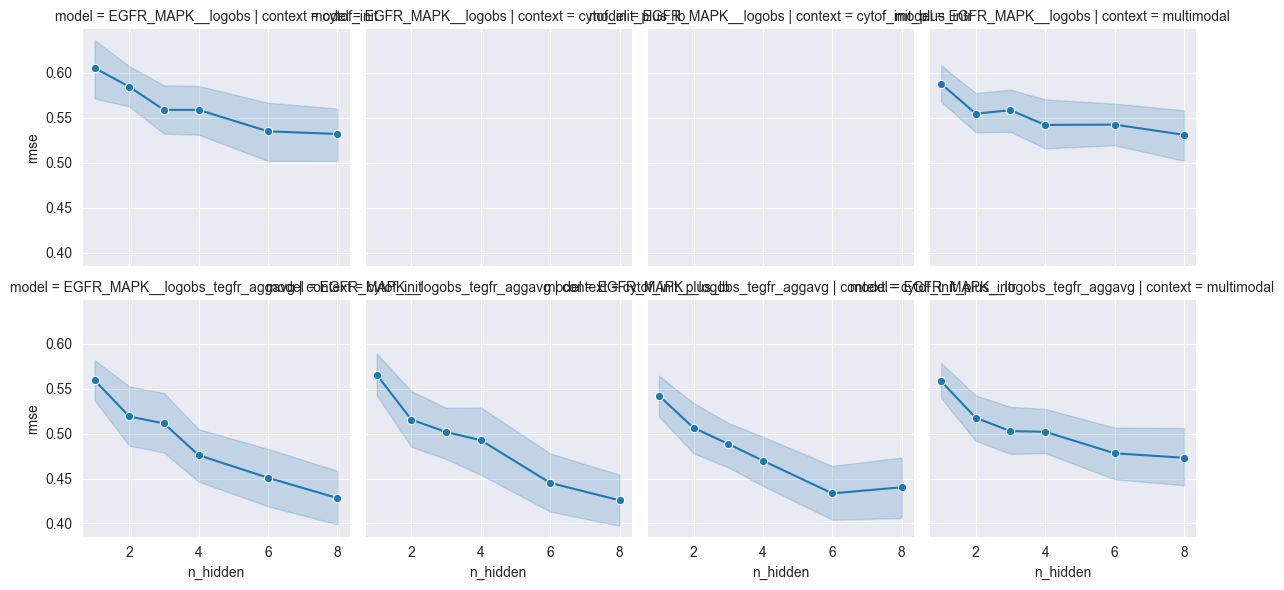

In [34]:
g = sns.FacetGrid(
    val_df[
        (val_df.ref == "DMM") & (val_df.dropout_rate == 0.1) & (val_df.recon_loss == 1e-4)
        & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr", "multimodal"],
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o'
)

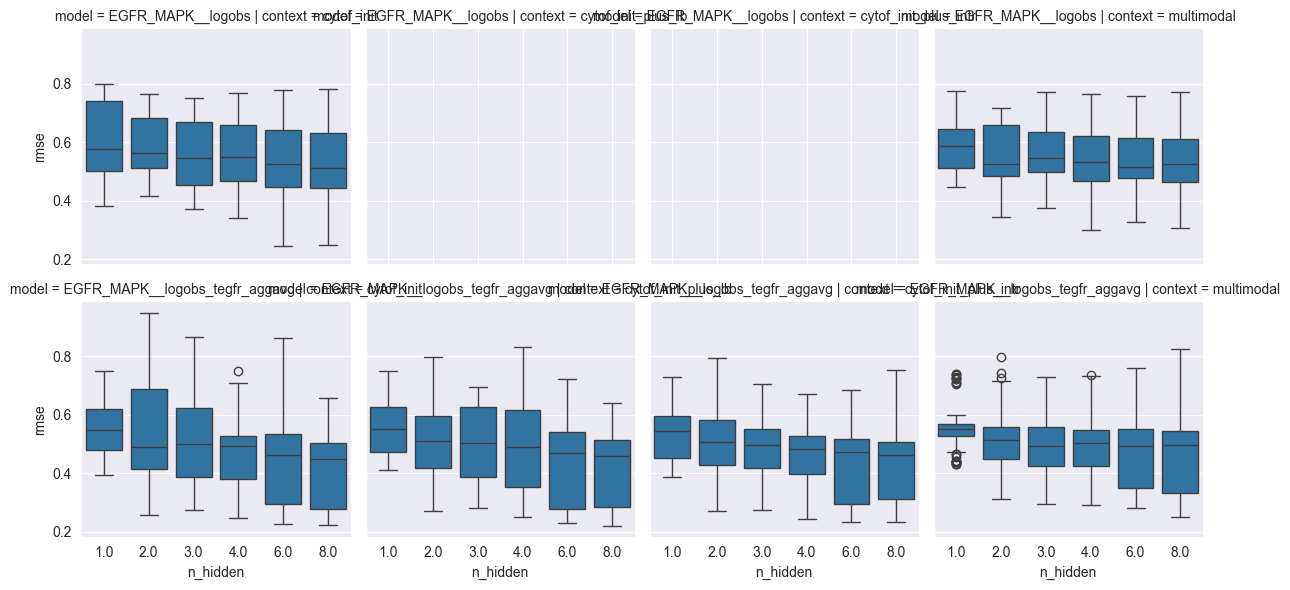

In [33]:
g = sns.FacetGrid(
    val_df[
        (val_df.ref == "DMM") & (val_df.dropout_rate == 0.1) & (val_df.recon_loss == 1e-4)
        & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr", "multimodal"],
)

g.map_dataframe(
    sns.boxplot,
    x="n_hidden",
    y="rmse",
)

In [12]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    num_contexts = int(len(df['context'].unique()))
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}; < 0.05/{num_contexts}={0.05/num_contexts}?: {p_value < 0.05/num_contexts}")

In [14]:
kruskal_wallis_groups(
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]))
        & (val_df.context.isin(["cytof_init", "multimodal"]))
    ],
    "rmse",
    "model"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=55.58, p-value=0.0000; < 0.05/2=0.025?: True
Context: multimodal - Kruskal-Wallis H-test: H-statistic=30.75, p-value=0.0000; < 0.05/2=0.025?: True


In [22]:
kruskal_wallis_groups(
    val_df[
        (val_df.ref.isin(["DMM"]))
        & (val_df.model.isin(["EGFR_MAPK__logobs_tegfr_aggavg"]))
        & (val_df.context.isin(["cytof_init", "multimodal"]))
        & (val_df.n_hidden.isin([2, 8]))
    ],
    "rmse",
    "n_hidden"
)

Context: cytof_init - Kruskal-Wallis H-test: H-statistic=11.85, p-value=0.0006; < 0.05/2=0.025?: True
Context: multimodal - Kruskal-Wallis H-test: H-statistic=3.44, p-value=0.0637; < 0.05/2=0.025?: False


Text(0.5, 1.05, 'RMSE difference between models vs n_hidden')

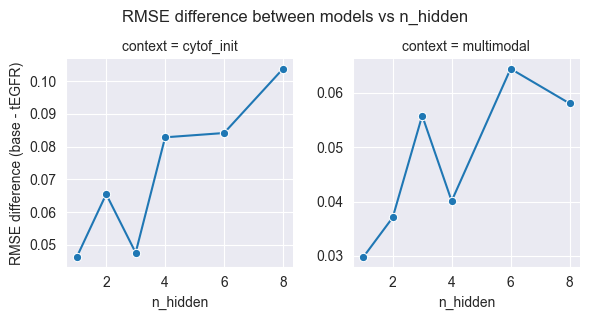

In [39]:
subset = val_df[
    (val_df.ref == "DMM")
    & (val_df.dropout_rate == 0.1)
    & (val_df.recon_loss == 1e-4)
    & (val_df.depth == 0)
    & (val_df.l1reg_inflater_output == 1e-2)
    & (val_df.l2reg_inflater_output == 0)
]

pivot = (
    subset
    .pivot_table(
        index=["context", "n_hidden"],
        columns="model",
        values="rmse"
    )
    .reset_index()
)

pivot["rmse_diff"] = (
    pivot["EGFR_MAPK__logobs"]
    - pivot["EGFR_MAPK__logobs_tegfr_aggavg"]
)

g = sns.FacetGrid(
    pivot,
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse_diff",
    marker="o"
)
g.set_axis_labels("n_hidden", "RMSE difference (base - tEGFR)")
g.fig.suptitle("RMSE difference between models vs n_hidden", y=1.05)